%pip install --user --force-reinstall "numpy<2"

%pip install --user --upgrade numexpr

!pip3 install --user xarray

!pip3 install --user netcdf4

!pip3 install --user matplotlib

!pip3 install --user cartopy

In [5]:
import xarray as xr

ds = xr.open_dataset("10exp_5pinatubo_rampupdecay_Raphael_2D_merged_conregridded_latlon360x180.nc")
ds

<xarray.Dataset> Size: 5GB
Dimensions:   (time: 480, lon: 360, lat: 180)
Coordinates:
  * time      (time) float64 4kB 2e+07 2e+07 2e+07 ... 2.039e+07 2.04e+07
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables: (12/43)
    orog      (lat, lon) float32 259kB ...
    ps        (time, lat, lon) float32 124MB ...
    psl       (time, lat, lon) float32 124MB ...
    cosmu0    (time, lat, lon) float32 124MB ...
    rsdt      (time, lat, lon) float32 124MB ...
    rsut      (time, lat, lon) float32 124MB ...
    ...        ...
    sfcwind   (time, lat, lon) float32 124MB ...
    uas       (time, lat, lon) float32 124MB ...
    vas       (time, lat, lon) float32 124MB ...
    tas       (time, lat, lon) float32 124MB ...
    dew2      (time, lat, lon) float32 124MB ...
    ptp       (time, lat, lon) float32 124MB ...
Attributes:
    CDI:          Climate Data Interface version 2.1.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    source:       Unknown@Unknown
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    history:      Sat Jun 06 14:01:10 2026: cdo remapcon,r360x180 -setgrid,/g...
    references:   see MPIM/DWD publications
    comment:      None ICON09 (icon09) on n4911-030 (Linux 4.18.0-477.10.1.el...
    CDO:          Climate Data Operators version 2.1.0 (https://mpimet.mpg.de...

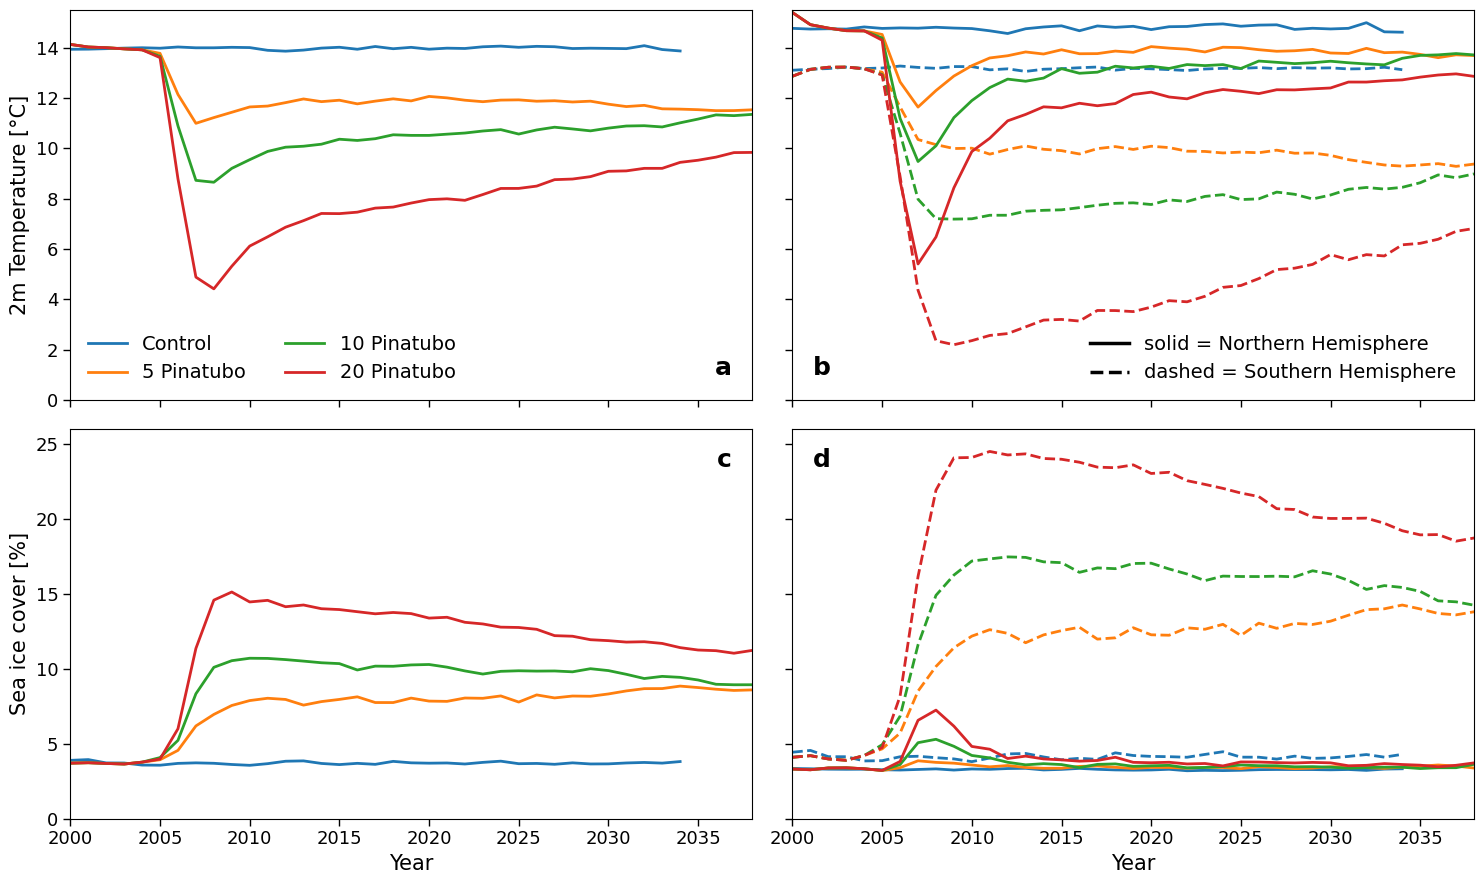

In [8]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


# 
# settings to make the plots more readable (since 4 subplots make everything tiny)
# 

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
})


# 
# setting main folder
# 

folder = Path("/gpfs/data/fs72044/icon09/data_analysis")


# 
# define the files we are going to use
# 

files = {
    "Control": "reference_2D_2000_2035_merged_conregridded_latlon360x180.nc",
    "5 Pinatubo": "10exp_5pinatubo_rampupdecay_Raphael_2D_merged_conregridded_latlon360x180.nc",
    "10 Pinatubo": "9exp_10pinatubo_rampupdecay_Raphael_2D_merged_regridded.nc",
    "20 Pinatubo": "11exp_20pinatubo_rampupdecay_Raphael_2D_merged_conregridded_latlon360x180.nc",
}


# 
# create figure with 4 subplots
# 

fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 9),
    sharex=True
)

ax_temp_global = axes[0, 0]
ax_temp_hemi   = axes[0, 1]

ax_sic_global = axes[1, 0]
ax_sic_hemi   = axes[1, 1]


# 
# file processing for each file
# 

for name, filename in files.items():

    file_path = folder / filename
    ds = xr.open_dataset(file_path)

    # the time is in float format, we need it as datetime. for that it first needs to be turned into a string.
    time_fixed = pd.to_datetime(
        ds["time"].values.astype(int).astype(str),
        format="%Y%m%d"
    )

    ds = ds.assign_coords(time=time_fixed)

    plot_name = name       


    # 
    ##### SEA ICE 
    # 

    sic = ds["sic"]
    sic_percent = sic * 100

    weights_global_sic = np.cos(np.deg2rad(sic_percent["lat"]))         #latitude weights as usual

    sic_global_mean = sic_percent.weighted(weights_global_sic).mean(     #for global means
        dim=("lat", "lon")
    )

    sic_north = sic_percent.where(sic_percent["lat"] >= 0, drop=True)     #for hemispherical means
    sic_south = sic_percent.where(sic_percent["lat"] < 0, drop=True)

    weights_north_sic = np.cos(np.deg2rad(sic_north["lat"]))
    weights_south_sic = np.cos(np.deg2rad(sic_south["lat"]))

    sic_north_mean = sic_north.weighted(weights_north_sic).mean(
        dim=("lat", "lon")
    )

    sic_south_mean = sic_south.weighted(weights_south_sic).mean(
        dim=("lat", "lon")
    )

    sic_global_yearly = sic_global_mean.groupby("time.year").mean()
    sic_north_yearly = sic_north_mean.groupby("time.year").mean()
    sic_south_yearly = sic_south_mean.groupby("time.year").mean()

    sic_global_yearly = sic_global_yearly.isel(year=slice(0, -1))
    sic_north_yearly = sic_north_yearly.isel(year=slice(0, -1))
    sic_south_yearly = sic_south_yearly.isel(year=slice(0, -1))

    # Global sea ice
    ax_sic_global.plot(
        sic_global_yearly["year"],
        sic_global_yearly,
        label=plot_name
    )

    # Hemispherical sea ice
    line_north_sic, = ax_sic_hemi.plot(
        sic_north_yearly["year"],
        sic_north_yearly,
        linestyle="-",
        label=plot_name if name == "Control" else None
    )

    ax_sic_hemi.plot(
        sic_south_yearly["year"],
        sic_south_yearly,
        linestyle="--",
        color=line_north_sic.get_color()
    )


    #
    ##### 2m TEMPERATURE
    #

    temp = ds["tas"]
    temp_celsius = temp - 273.15

    weights_global_temp = np.cos(np.deg2rad(temp_celsius["lat"]))         #as above, weights

    temp_global_mean = temp_celsius.weighted(weights_global_temp).mean(
        dim=("lat", "lon")
    )

    temp_north = temp_celsius.where(temp_celsius["lat"] >= 0, drop=True)      #for hemispherical means
    temp_south = temp_celsius.where(temp_celsius["lat"] < 0, drop=True)

    weights_north_temp = np.cos(np.deg2rad(temp_north["lat"]))
    weights_south_temp = np.cos(np.deg2rad(temp_south["lat"]))

    temp_north_mean = temp_north.weighted(weights_north_temp).mean(
        dim=("lat", "lon")
    )

    temp_south_mean = temp_south.weighted(weights_south_temp).mean(
        dim=("lat", "lon")
    )

    temp_global_yearly = temp_global_mean.groupby("time.year").mean()
    temp_north_yearly = temp_north_mean.groupby("time.year").mean()
    temp_south_yearly = temp_south_mean.groupby("time.year").mean()

    temp_global_yearly = temp_global_yearly.isel(year=slice(0, -1))
    temp_north_yearly = temp_north_yearly.isel(year=slice(0, -1))
    temp_south_yearly = temp_south_yearly.isel(year=slice(0, -1))

    # Global 2 m temperature
    ax_temp_global.plot(
        temp_global_yearly["year"],
        temp_global_yearly,
        label=plot_name
    )

    # Hemispherical 2 m temperature
    line_north_temp, = ax_temp_hemi.plot(
        temp_north_yearly["year"],
        temp_north_yearly,
        linestyle="-",
        label=plot_name if name == "Control" else None
    )

    ax_temp_hemi.plot(
        temp_south_yearly["year"],
        temp_south_yearly,
        linestyle="--",
        color=line_north_temp.get_color()
    )

    ds.close()


# 
###### Adjust axes
# 

label_fs = 15                    #for readability
tick_fs = 13
legend_fs = 14

for ax in axes.flat:
    ax.set_xlim(2000, 2038)
    ax.grid(False)

    # Larger axis numbers
    ax.tick_params(axis="both", labelsize=tick_fs)

    # More visible tick marks
    ax.tick_params(axis="both", length=5, width=1)

# y-axis limits
ax_temp_global.set_ylim(0, 15.5)
ax_temp_hemi.set_ylim(0, 15.5)

ax_sic_global.set_ylim(0, 26)
ax_sic_hemi.set_ylim(0, 26)

# Remove y-axis numbers on right plots, keep tick marks
ax_temp_hemi.tick_params(axis="y", labelleft=False)
ax_sic_hemi.tick_params(axis="y", labelleft=False)

# Axis labels
ax_temp_global.set_ylabel("2m Temperature [°C]", fontsize=label_fs)
ax_sic_global.set_ylabel("Sea ice cover [%]", fontsize=label_fs)

ax_sic_global.set_xlabel("Year", fontsize=label_fs)
ax_sic_hemi.set_xlabel("Year", fontsize=label_fs)


# 
###### Add panel labels (location of a, b, c, d, it's a bit tricky since we want them in very precise spots)
# 

panel_labels = {
    ax_temp_global: ("a", 0.97, 0.05, "right", "bottom"),
    ax_temp_hemi:   ("b", 0.03, 0.05, "left",  "bottom"),
    ax_sic_global:  ("c", 0.97, 0.95, "right", "top"),
    ax_sic_hemi:    ("d", 0.03, 0.95, "left",  "top"),
}

for ax, (label, x_pos, y_pos, ha, va) in panel_labels.items():
    ax.text(
        x_pos, y_pos, label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        ha=ha,
        va=va
    )


# 
# We want separate legends for clarity 
# 

# Legend in the global temperature plot
handles, labels = ax_temp_global.get_legend_handles_labels()

ax_temp_global.legend(
    handles=handles,
    frameon=False,
    ncol=2,
    fontsize=legend_fs
)


# Legend for solid/dashed in the hemispherical temperature plot
solid_line = Line2D(
    [0], [0],
    linestyle="-",
    color="black",
    linewidth=2.5,
    label="solid = Northern Hemisphere"
)

dashed_line = Line2D(
    [0], [0],
    linestyle="--",
    color="black",
    linewidth=2.5,
    label="dashed = Southern Hemisphere"
)

ax_temp_hemi.legend(
    handles=[solid_line, dashed_line],
    frameon=False,
    loc="best",
    fontsize=legend_fs
)


# 
#### Layout and save
#

plt.tight_layout()

plt.savefig(
    folder / "temperature_sea_ice_timeseries_4panel.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

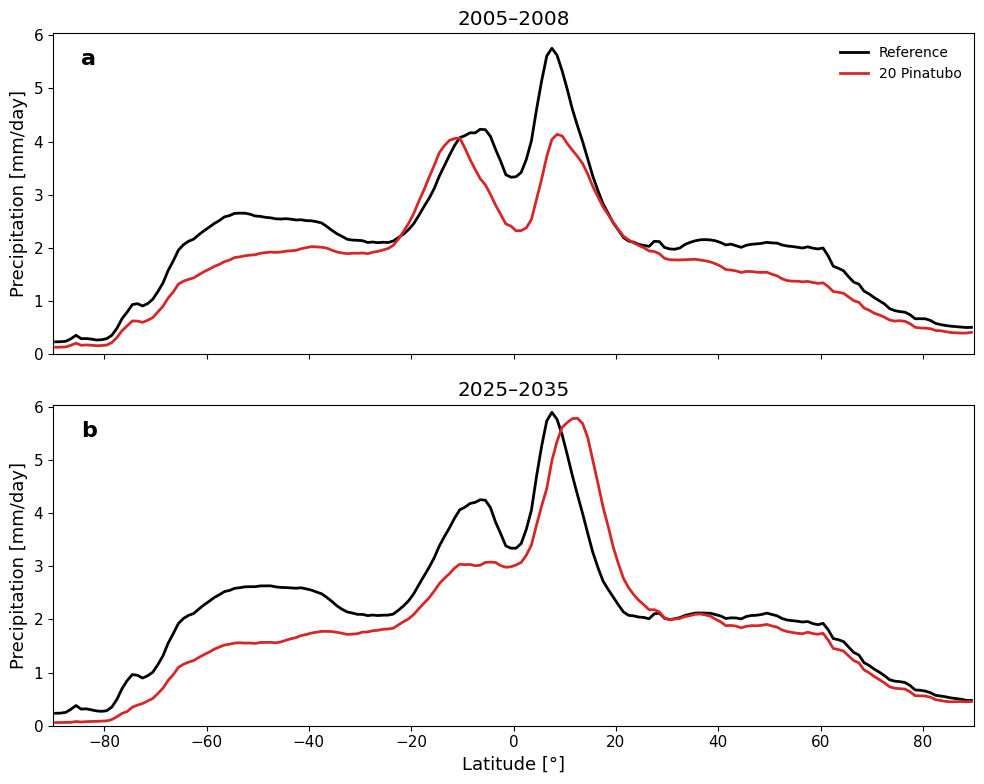

In [7]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


#
##### Set folder
#

folder = Path("/gpfs/data/fs72044/icon09/data_analysis")


#
##### Select files
#

files = {
    "Reference": "reference_2D_2000_2035_merged_conregridded_latlon360x180.nc",
    "20 Pinatubo": "11exp_20pinatubo_rampupdecay_Raphael_2D_merged_conregridded_latlon360x180.nc",
}


#
# colours of lines in plot
#

colors = {
    "Reference": "black",
    "20 Pinatubo": "tab:red",
}


# 
# time periods to take the mean over and plot
#

periods = {
    "2005–2008": (2005, 2008),
    "2025–2035": (2025, 2035),
}


# 
##### define a function for precipitation by latitude
# 

def get_precip_lat_profile(file_path, start_year, end_year):

    # Open dataset
    ds = xr.open_dataset(file_path)

    # again, time is given in float format, this needs to be fixed. .to_datetime exects a string
    time_fixed = pd.to_datetime(
        ds["time"].values.astype(int).astype(str),
        format="%Y%m%d"
    )
    ds = ds.assign_coords(time=time_fixed)

    # Select precipitation
    # Unit: kg m-2 s-1
    pr = ds["pr"]

    # Convert to mm/day
    # kg m-2 s-1 is equivalent to mm/s for our purposes here
    pr_mm_day = pr * 86400

    # Calculate annual means
    pr_yearly = pr_mm_day.groupby("time.year").mean("time")

    # Remove last year because it is faulty
    pr_yearly = pr_yearly.isel(year=slice(0, -1))

    # Select desired time period
    pr_period = pr_yearly.sel(
        year=slice(start_year, end_year)
    )

    # Average over selected years and longitudes
    # Result keeps only latitude
    lat_profile = pr_period.mean(dim=("year", "lon"))

    return lat_profile


# 
# Create figure with two panels
# 

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)


#
# Plot both periods
# 

panel_labels = ["a", "b"]

for ax, (period_name, years), label in zip(axes, periods.items(), panel_labels):

    start_year, end_year = years

    for name, filename in files.items():

        file_path = folder / filename

        profile = get_precip_lat_profile(
            file_path,
            start_year,
            end_year
        )

        ax.plot(
            profile["lat"],
            profile,
            color=colors[name],
            linewidth=2,
            label=name
        )
        
    ax.set_xlim(-90, 90)
    ax.set_ylim(bottom=0)

    ax.set_title(period_name)
    ax.set_ylabel("Precipitation [mm/day]")
    ax.grid(False)

    # Panel label in the top left
    ax.text(
        0.03, 0.95, label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="top"
    )

    # Only one legend for both plots, without box
    if ax == axes[0]:
        ax.legend(frameon=False)


# lavel x axis
axes[-1].set_xlabel("Latitude [°]")


#layout
plt.tight_layout()


# save plot
plt.savefig(
    folder / "precipitation_by_latitude_two_periods_reference_vs_20pinatubo.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()